# EDA — Predicción de Formaciones SENA

**Dataset:** Fichas de formación del Centro para la Biodiversidad y el Turismo del Amazonas  
**Fuente:** Sistema Sofia Plus — Reportes DF-14A y DF-08  
**Contexto:** Predecir aperturas trimestrales, deserción y recomendar formaciones (Técnico, Tecnólogo, Operario).  
**Dimensiones:** 153 fichas × 38 variables  
**Tipo de problema:** Clasificación + Regresión  

**Integrantes:** *(Yeison Acero - Michael Cardenas)*

## 0. Importaciones y configuración

In [1]:
%pip install pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

COLORS = {'TÉCNICO':'#378ADD', 'TECNÓLOGO':'#1D9E75', 'OPERARIO':'#D85A30'}
PALETTE = list(COLORS.values())

# El CSV debe estar en el mismo directorio que este notebook
DATA_PATH = 'dataset_formacion_sena.csv'
print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 1. Inspección inicial y estadísticas descriptivas

In [3]:
df = pd.read_csv(DATA_PATH)
df['FECHA_INICIO_FICHA'] = pd.to_datetime(df['FECHA_INICIO_FICHA'], errors='coerce')
df['FECHA_FIN_FICHA']    = pd.to_datetime(df['FECHA_FIN_FICHA'],    errors='coerce')

print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Periodo: {df["FECHA_INICIO_FICHA"].min().date()} a {df["FECHA_INICIO_FICHA"].max().date()}')
print(f'Niveles: {df["NIVEL_FORMACION"].unique()}')
df.head(5)

Dimensiones: 153 filas x 38 columnas
Periodo: 2022-10-06 a 2026-05-28
Niveles: <StringArray>
['OPERARIO', 'TÉCNICO', 'TECNÓLOGO']
Length: 3, dtype: str


,FICHA,CODIGO_PROGRAMA,PROGRAMA,NIVEL_FORMACION,FECHA_INICIO_FICHA,FECHA_FIN_FICHA,AÑO_APERTURA,MES_APERTURA,TRIMESTRE_APERTURA,DURACION_MAXIMA,...,CANCELADO,DESERCION_VIRT_COMP,CANCELAMIENTO_VIRT_COMP,POR_CERTIFICAR,CERTIFICADO,TRASLADADO,OTRO,TOTAL_DESERCION,TASA_DESERCION,TASA_CERTIFICACION
0,2822003,836201,CONSTRUCCION DE ESTRUCTURAS EN CONCRETO,OPERARIO,2023-08-28,2025-07-25,2023,8,3,1296,...,15,0,0,0,5,0,0,15,0.6818,0.2273
1,3112005,836201,CONSTRUCCION DE ESTRUCTURAS EN CONCRETO,OPERARIO,2024-10-25,2025-08-30,2024,10,4,1296,...,17,0,0,0,8,0,0,17,0.6538,0.3077
2,3334901,836201,CONSTRUCCION DE ESTRUCTURAS EN CONCRETO,OPERARIO,2025-10-09,2027-02-20,2025,10,4,1296,...,7,0,0,0,0,0,0,8,0.3077,0.0000
3,3171467,832235,INSTALACIONES ELECTRICAS PARA VIVIENDAS,OPERARIO,2025-04-29,2026-01-26,2025,4,2,880,...,0,0,0,0,1,0,0,1,0.0556,0.0556
4,3214523,935105,MANEJO DE MAQUINARIA DE CONFECCION INDUSTRIAL ...,OPERARIO,2025-04-29,2026-03-22,2025,4,2,1296,...,12,0,0,0,0,0,0,12,0.5000,0.0000


In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print('=== Estadísticas descriptivas ===')
df[num_cols].describe().round(2)

=== Estadísticas descriptivas ===


,FICHA,CODIGO_PROGRAMA,AÑO_APERTURA,MES_APERTURA,TRIMESTRE_APERTURA,DURACION_MAXIMA,DURACION_ETAPA_LECTIVA,DURACION_ETAPA_PRODUCTIVA,CUPO,TOTAL_MATRICULADOS,...,CANCELADO,DESERCION_VIRT_COMP,CANCELAMIENTO_VIRT_COMP,POR_CERTIFICAR,CERTIFICADO,TRASLADADO,OTRO,TOTAL_DESERCION,TASA_DESERCION,TASA_CERTIFICACION
count,153.00,153.00,153.00,153.00,153.00,153.00,153.00,153.00,153.00,153.00,...,153.00,153.0,153.0,153.00,153.00,153.00,153.0,153.00,153.00,153.00
mean,3112321.80,424700.98,2024.54,5.22,2.10,2334.95,1517.40,817.56,33.10,27.88,...,3.84,0.0,0.0,0.14,3.76,0.99,0.0,6.84,0.24,0.14
std,218264.52,262577.66,0.97,3.26,1.24,780.36,677.79,178.84,8.67,9.47,...,6.22,0.0,0.0,0.55,6.03,3.35,0.0,7.88,0.23,0.22
min,2631764.00,112005.00,2022.00,1.00,1.00,24.00,18.00,6.00,15.00,7.00,...,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,2911026.00,134400.00,2024.00,2.00,1.00,2200.00,1320.00,864.00,27.00,23.00,...,0.00,0.0,0.0,0.00,0.00,0.00,0.0,1.00,0.03,0.00
50%,3147934.00,331120.00,2025.00,4.00,2.00,2208.00,1344.00,864.00,30.00,25.00,...,0.00,0.0,0.0,0.00,0.00,0.00,0.0,6.00,0.22,0.00
75%,3291298.00,637200.00,2025.00,8.00,3.00,2304.00,1440.00,880.00,35.00,30.00,...,6.00,0.0,0.0,0.00,7.00,0.00,0.0,10.00,0.40,0.28
max,3494865.00,935105.00,2026.00,12.00,4.00,3984.00,3120.00,880.00,70.00,71.00,...,37.00,0.0,0.0,4.00,24.00,21.00,0.0,52.00,0.88,0.82


In [5]:
for c in df.select_dtypes(include='object').columns:
    print(f'\n{c} ({df[c].nunique()} únicos):')
    print(df[c].value_counts().to_string())


PROGRAMA (42 únicos):
PROGRAMA
ASISTENCIA ADMINISTRATIVA .                                                  21
OPERACION TURISTICA LOCAL                                                    15
SISTEMAS TELEINFORMÁTICOS                                                    13
PRODUCCION AGROPECUARIA                                                      10
ASISTENCIA EN ORGANIZACION DE ARCHIVOS .                                      6
SISTEMAS AGROPECUARIOS ECOLOGICOS.                                            6
.ATENCION INTEGRAL A LA PRIMERA INFANCIA                                      5
ANALISIS Y DESARROLLO DE SOFTWARE.                                            5
GESTIÓN DEL TALENTO HUMANO                                                    5
ENFERMERIA.                                                                   4
MANTENIMIENTO DE EQUIPOS DE AIRE ACONDICIONADO Y REFRIGERACION                4
PELUQUERIA.                                                                   4
SALUD OR

## 2. Análisis de valores faltantes

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_pct})
missing_df = missing_df[missing_df['Faltantes'] > 0]

if missing_df.empty:
    print('Sin valores faltantes.')
    print('Tratamiento previo:')
    print('  JORNADA/LINEA sin match en DF-08 → NO DEFINIDA')
    print('  CONVENIO sin valor → SIN CONVENIO')
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(8,4))
    ax.barh(missing_df.index, missing_df['Porcentaje'], color='#E24B4A')
    ax.set_xlabel('% faltante')
    ax.set_title('Variables con valores faltantes')
    plt.tight_layout(); plt.show()

Sin valores faltantes.
Tratamiento previo:
  JORNADA/LINEA sin match en DF-08 → NO DEFINIDA
  CONVENIO sin valor → SIN CONVENIO


## 3. Distribución de la variable objetivo

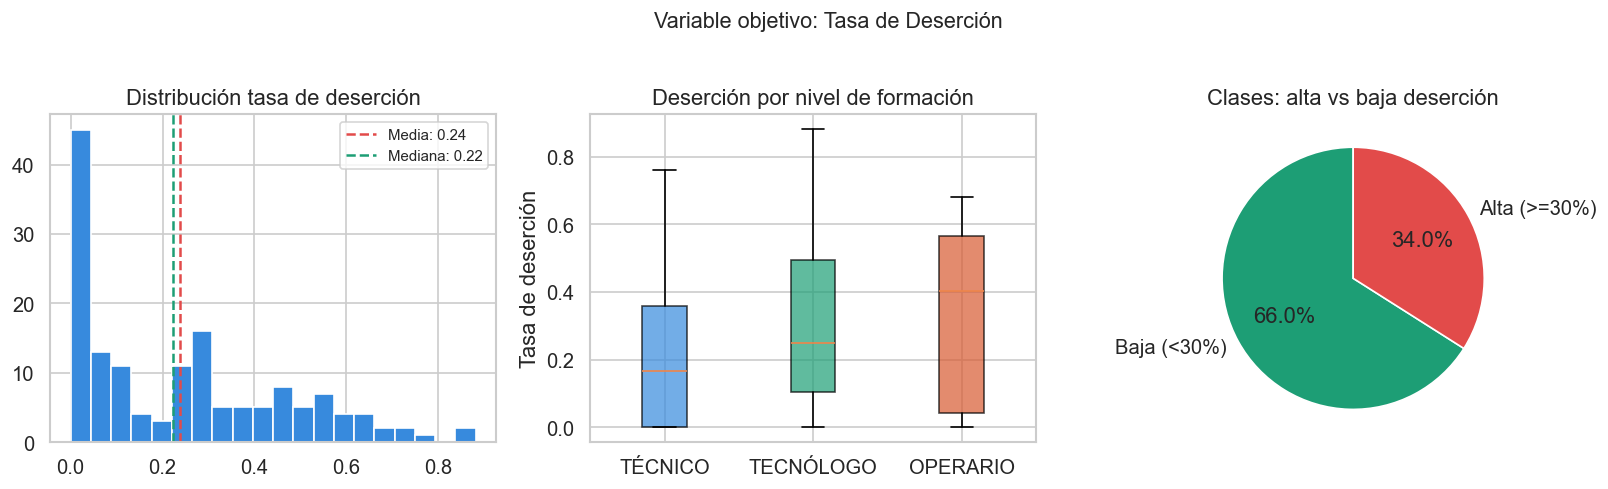

Desbalance:
ALTA_DESERCION
Baja    0.660131
Alta    0.339869


In [7]:
df['ALTA_DESERCION'] = (df['TASA_DESERCION'] >= 0.30).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(14,4))

axes[0].hist(df['TASA_DESERCION'], bins=20, color='#378ADD', edgecolor='white')
axes[0].axvline(df['TASA_DESERCION'].mean(), color='#E24B4A', linestyle='--',
    label=f'Media: {df["TASA_DESERCION"].mean():.2f}')
axes[0].axvline(df['TASA_DESERCION'].median(), color='#1D9E75', linestyle='--',
    label=f'Mediana: {df["TASA_DESERCION"].median():.2f}')
axes[0].set_title('Distribución tasa de deserción')
axes[0].legend(fontsize=9)

data_niv = [df[df['NIVEL_FORMACION']==n]['TASA_DESERCION'].values for n in COLORS]
bp = axes[1].boxplot(data_niv, patch_artist=True, labels=list(COLORS.keys()))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Deserción por nivel de formación')
axes[1].set_ylabel('Tasa de deserción')

counts = df['ALTA_DESERCION'].value_counts()
axes[2].pie(counts.values, labels=['Baja (<30%)','Alta (>=30%)'],
    colors=['#1D9E75','#E24B4A'], autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor':'white'})
axes[2].set_title('Clases: alta vs baja deserción')

plt.suptitle('Variable objetivo: Tasa de Deserción', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print('Desbalance:')
print(df['ALTA_DESERCION'].value_counts(normalize=True).rename({0:'Baja',1:'Alta'}).to_string())

## 4. Análisis univariado

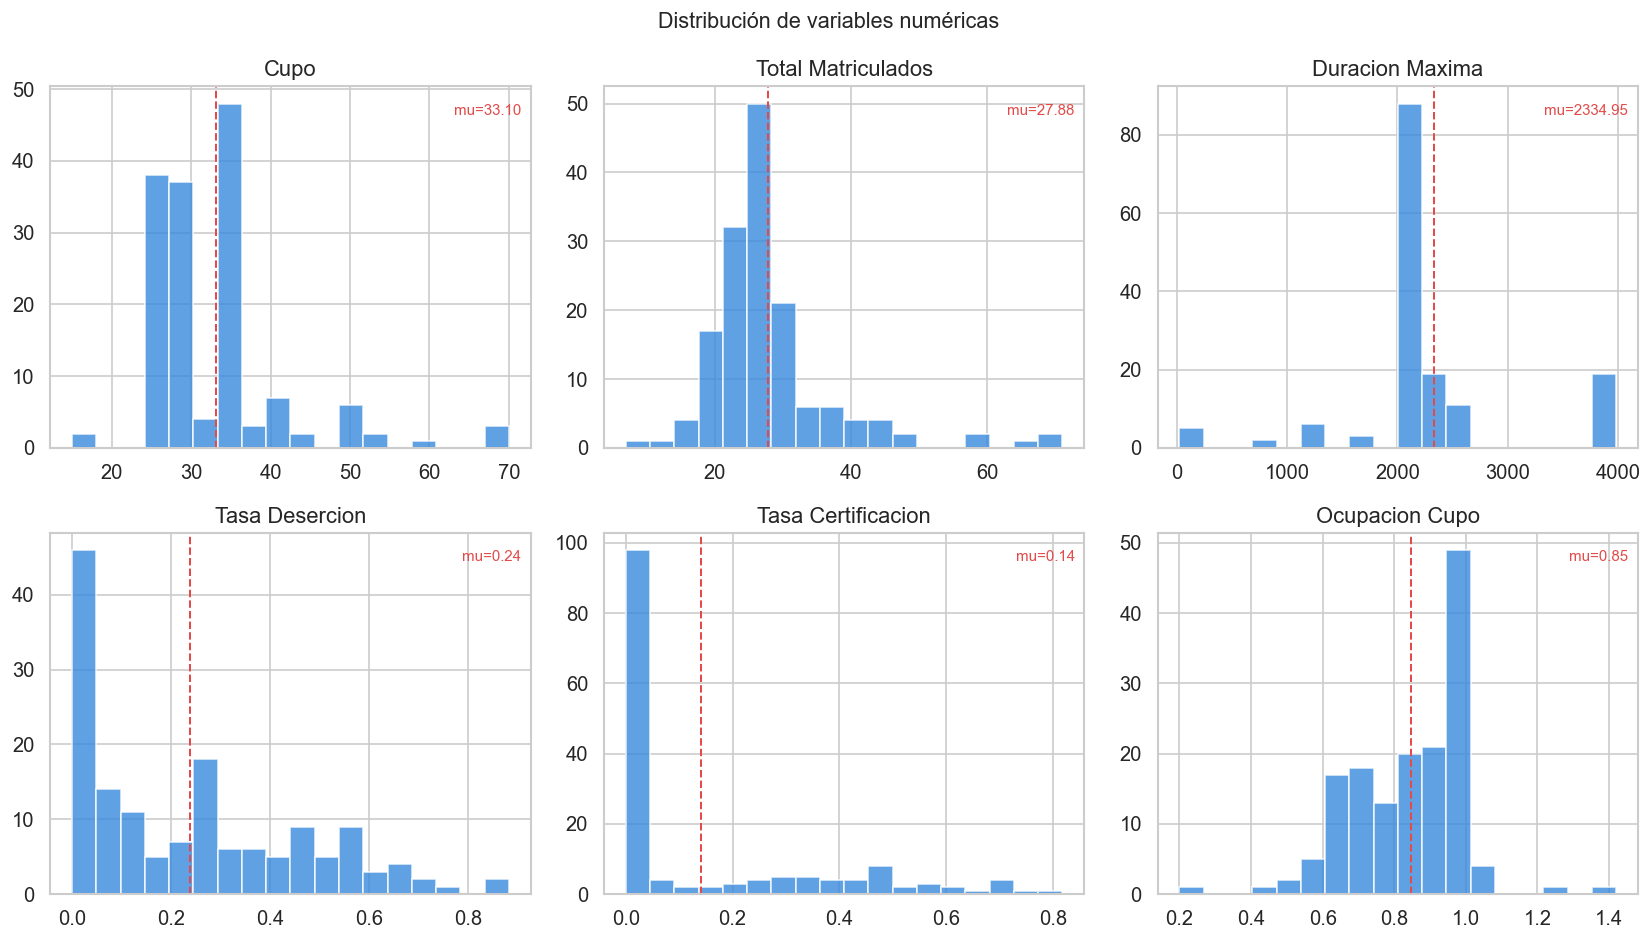

In [8]:
vars_num = ['CUPO','TOTAL_MATRICULADOS','DURACION_MAXIMA',
            'TASA_DESERCION','TASA_CERTIFICACION','OCUPACION_CUPO']

fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

for i, col in enumerate(vars_num):
    axes[i].hist(df[col], bins=18, color='#378ADD', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_',' ').title())
    mean_v = df[col].mean()
    axes[i].axvline(mean_v, color='#E24B4A', linestyle='--', linewidth=1.2)
    axes[i].text(0.98, 0.92, f'mu={mean_v:.2f}', transform=axes[i].transAxes,
                 ha='right', fontsize=9, color='#E24B4A')

plt.suptitle('Distribución de variables numéricas', fontsize=13)
plt.tight_layout(); plt.show()

In [9]:
print('=== Outliers (metodo IQR) ===')
for col in vars_num:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    out = df[(df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)]
    print(f'  {col}: {len(out)} outliers ({len(out)/len(df)*100:.1f}%)')

=== Outliers (metodo IQR) ===
  CUPO: 12 outliers (7.8%)
  TOTAL_MATRICULADOS: 14 outliers (9.2%)
  DURACION_MAXIMA: 46 outliers (30.1%)
  TASA_DESERCION: 0 outliers (0.0%)
  TASA_CERTIFICACION: 4 outliers (2.6%)
  OCUPACION_CUPO: 1 outliers (0.7%)


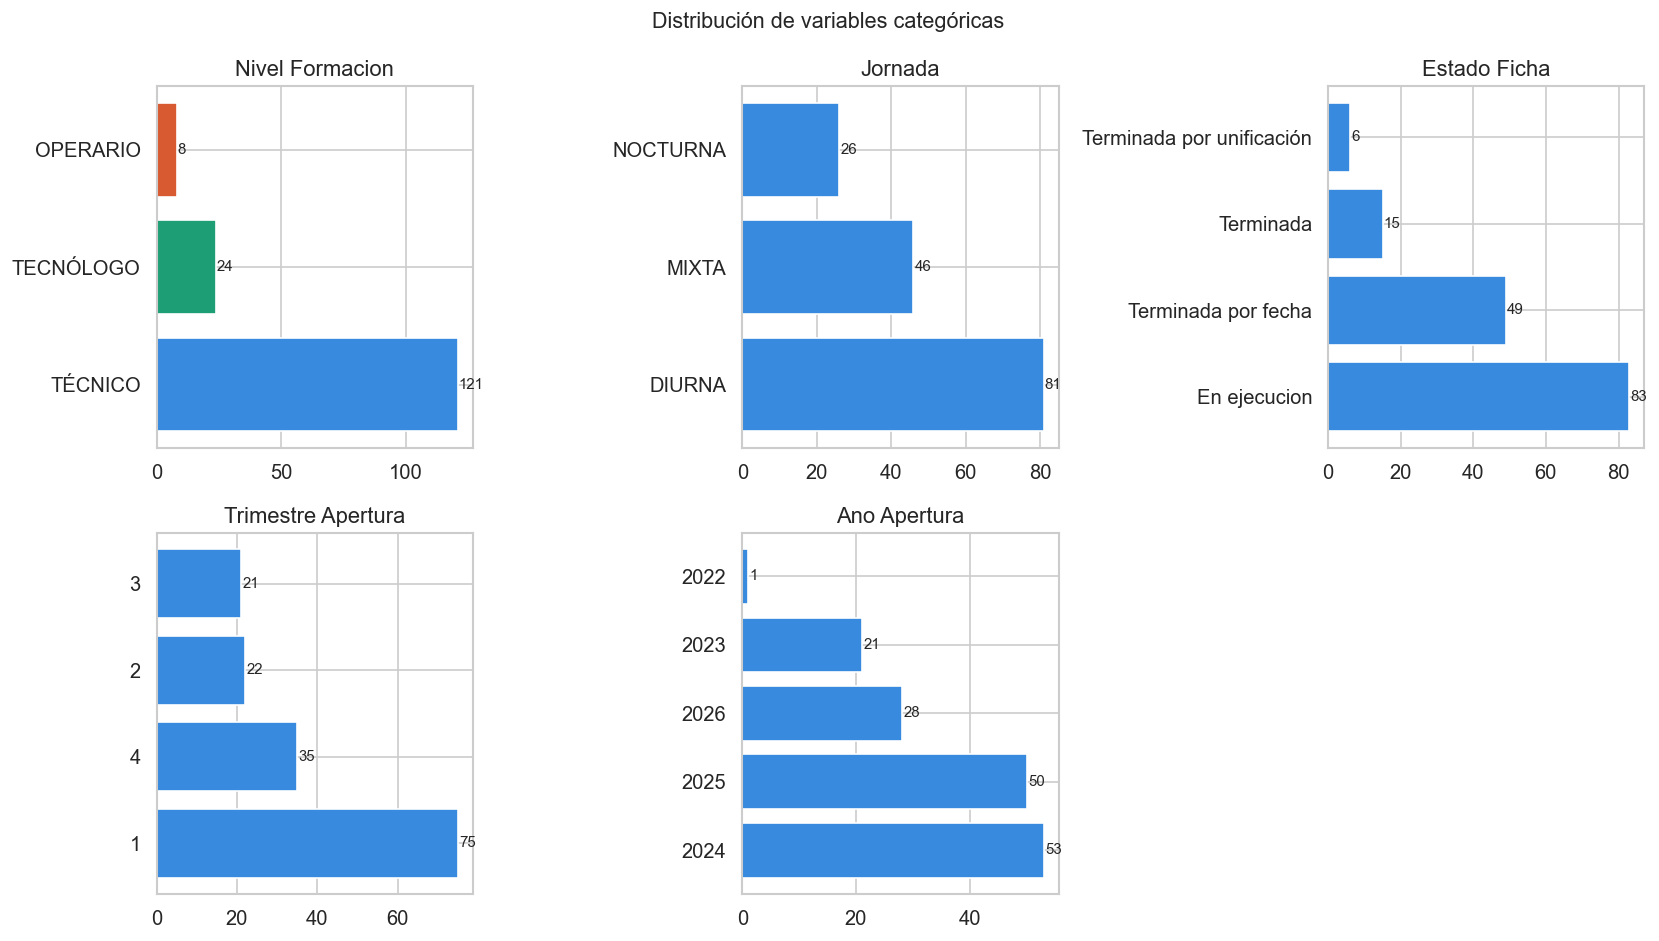

In [10]:
vars_cat = ['NIVEL_FORMACION','JORNADA','ESTADO_FICHA','TRIMESTRE_APERTURA','ANO_APERTURA']
# Renombrar temporalmente para graficar
df['ANO_APERTURA'] = df['AÑO_APERTURA']

fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

for i, col in enumerate(vars_cat):
    vc = df[col].value_counts()
    color_b = PALETTE[:len(vc)] if col=='NIVEL_FORMACION' else ['#378ADD']*len(vc)
    axes[i].barh(vc.index.astype(str), vc.values, color=color_b, edgecolor='white')
    axes[i].set_title(col.replace('_',' ').title())
    for j, v in enumerate(vc.values):
        axes[i].text(v+0.3, j, str(v), va='center', fontsize=9)

axes[5].axis('off')
plt.suptitle('Distribución de variables categóricas', fontsize=13)
plt.tight_layout(); plt.show()

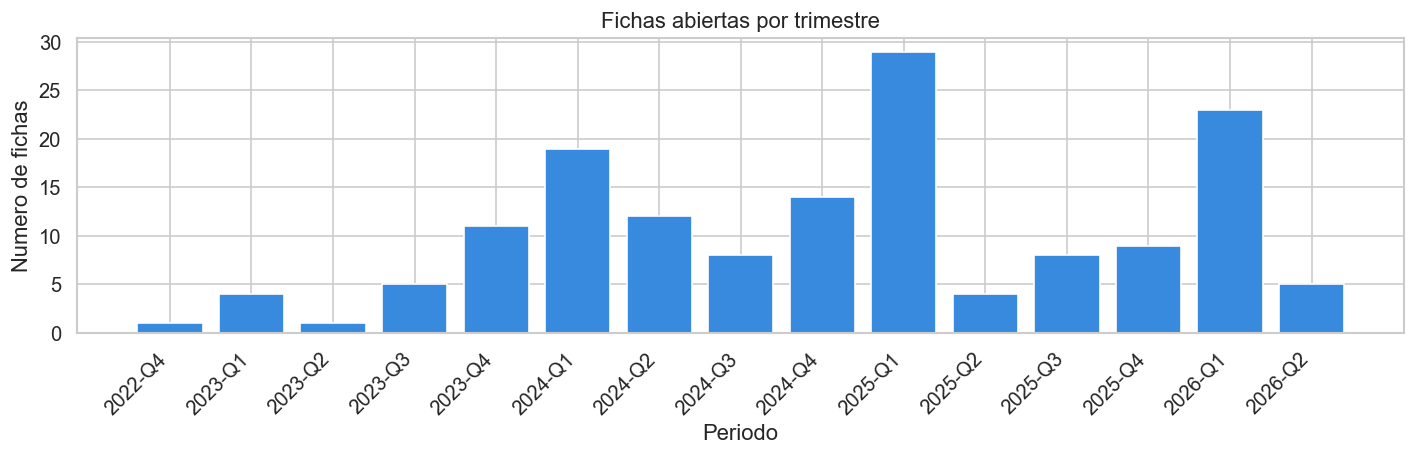

In [11]:
pivot_trim = df.groupby(['AÑO_APERTURA','TRIMESTRE_APERTURA']).size().reset_index(name='FICHAS')
pivot_trim['PERIODO'] = pivot_trim['AÑO_APERTURA'].astype(str) + '-Q' + pivot_trim['TRIMESTRE_APERTURA'].astype(str)

fig, ax = plt.subplots(figsize=(12,4))
ax.bar(pivot_trim['PERIODO'], pivot_trim['FICHAS'], color='#378ADD', edgecolor='white')
ax.set_title('Fichas abiertas por trimestre')
ax.set_xlabel('Periodo'); ax.set_ylabel('Numero de fichas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 5. Análisis bivariado

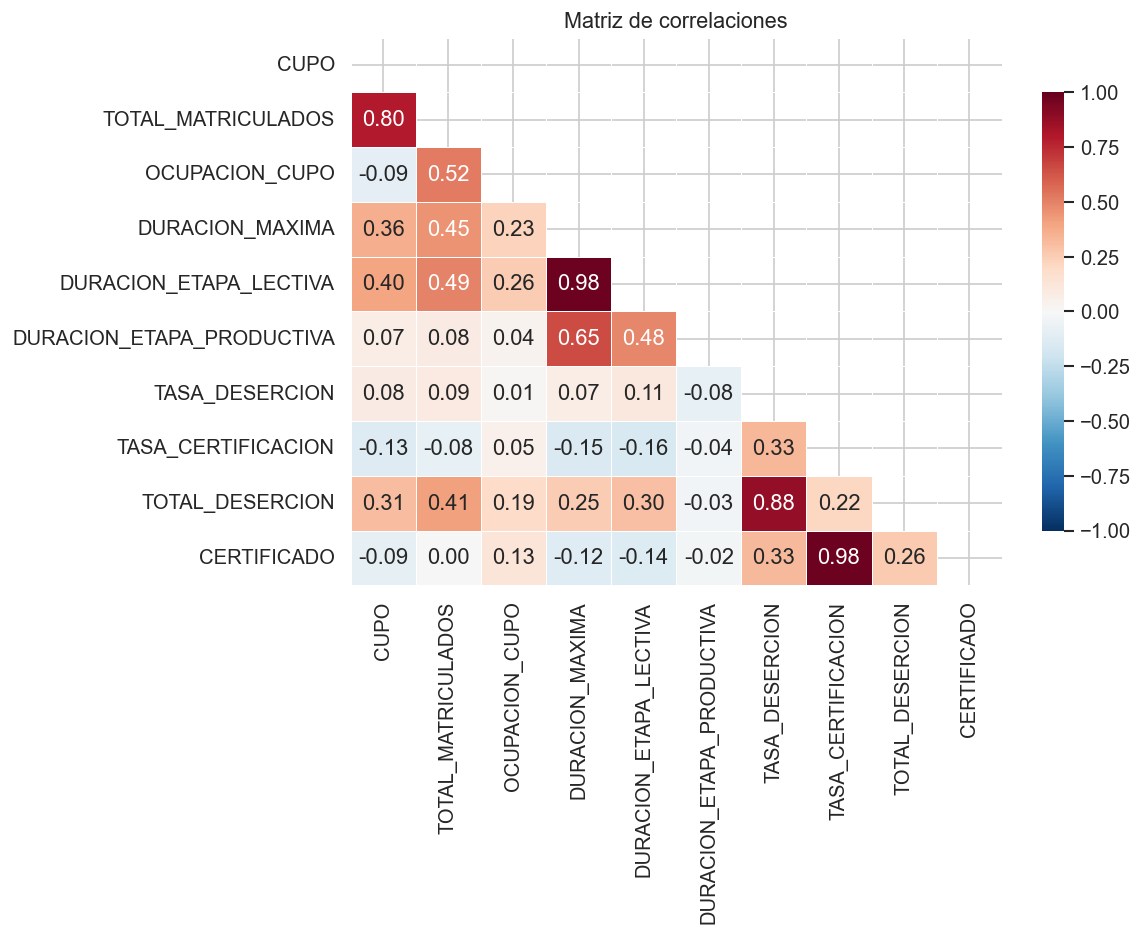

Correlaciones con TASA_DESERCION:
DURACION_ETAPA_PRODUCTIVA   -0.079646
OCUPACION_CUPO               0.012612
DURACION_MAXIMA              0.073756
CUPO                         0.080304
TOTAL_MATRICULADOS           0.091606
DURACION_ETAPA_LECTIVA       0.105933
CERTIFICADO                  0.325626
TASA_CERTIFICACION           0.328686
TOTAL_DESERCION              0.879332


In [12]:
corr_cols = ['CUPO','TOTAL_MATRICULADOS','OCUPACION_CUPO','DURACION_MAXIMA',
             'DURACION_ETAPA_LECTIVA','DURACION_ETAPA_PRODUCTIVA',
             'TASA_DESERCION','TASA_CERTIFICACION','TOTAL_DESERCION','CERTIFICADO']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, cbar_kws={'shrink':0.8})
ax.set_title('Matriz de correlaciones', fontsize=13)
plt.tight_layout(); plt.show()

print('Correlaciones con TASA_DESERCION:')
print(corr_matrix['TASA_DESERCION'].drop('TASA_DESERCION').sort_values().to_string())

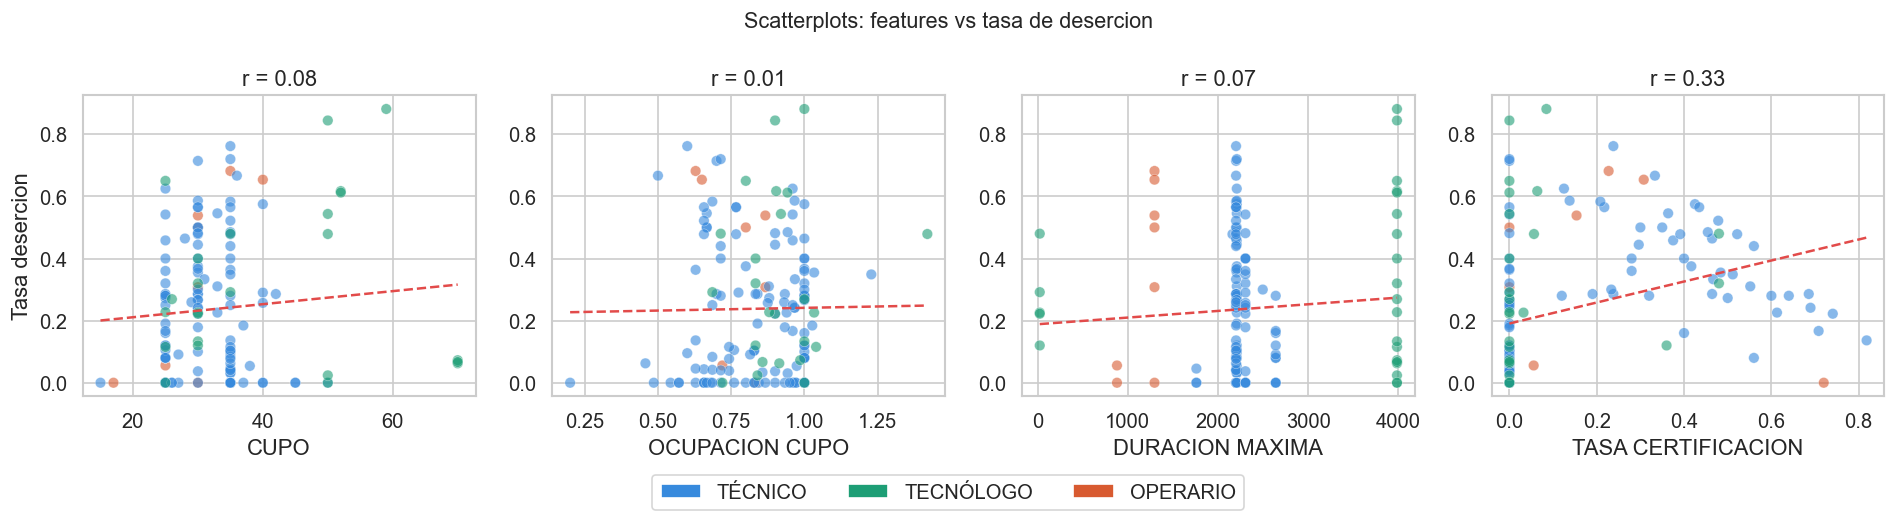

In [13]:
scatter_vars = ['CUPO','OCUPACION_CUPO','DURACION_MAXIMA','TASA_CERTIFICACION']
fig, axes = plt.subplots(1, 4, figsize=(16,4))
nivel_colors = df['NIVEL_FORMACION'].map(COLORS)

for i, var in enumerate(scatter_vars):
    axes[i].scatter(df[var], df['TASA_DESERCION'], c=nivel_colors, alpha=0.6, s=40,
                    edgecolors='white', linewidth=0.3)
    m, b, r, p, _ = stats.linregress(df[var].fillna(0), df['TASA_DESERCION'])
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    axes[i].plot(x_line, m*x_line+b, color='#E24B4A', linewidth=1.5, linestyle='--')
    axes[i].set_xlabel(var.replace('_',' '))
    axes[i].set_ylabel('Tasa desercion' if i==0 else '')
    axes[i].set_title(f'r = {r:.2f}')

legend_elements = [Patch(facecolor=c, label=n) for n, c in COLORS.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5,-0.08))
plt.suptitle('Scatterplots: features vs tasa de desercion', fontsize=13)
plt.tight_layout(); plt.show()

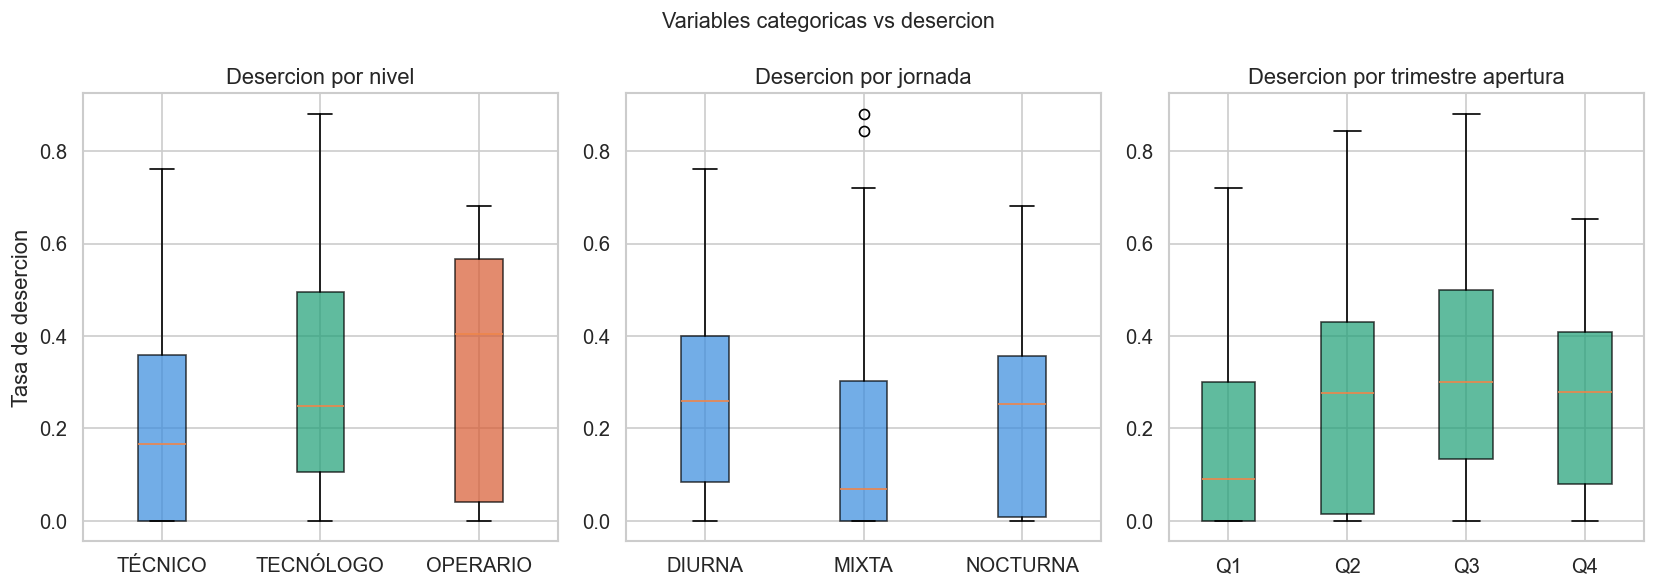

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14,5))

niveles_ord = ['TÉCNICO','TECNÓLOGO','OPERARIO']
data_niv = [df[df['NIVEL_FORMACION']==n]['TASA_DESERCION'].values for n in niveles_ord]
bp1 = axes[0].boxplot(data_niv, patch_artist=True, labels=niveles_ord)
for patch, color in zip(bp1['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('Desercion por nivel')
axes[0].set_ylabel('Tasa de desercion')

jornadas = df['JORNADA'].value_counts().index[:4].tolist()
data_jor = [df[df['JORNADA']==j]['TASA_DESERCION'].values for j in jornadas]
bp2 = axes[1].boxplot(data_jor, patch_artist=True, labels=[j[:8] for j in jornadas])
for patch in bp2['boxes']: patch.set_facecolor('#378ADD'); patch.set_alpha(0.7)
axes[1].set_title('Desercion por jornada')

trims = sorted(df['TRIMESTRE_APERTURA'].unique())
data_trim = [df[df['TRIMESTRE_APERTURA']==t]['TASA_DESERCION'].values for t in trims]
bp3 = axes[2].boxplot(data_trim, patch_artist=True, labels=[f'Q{t}' for t in trims])
for patch in bp3['boxes']: patch.set_facecolor('#1D9E75'); patch.set_alpha(0.7)
axes[2].set_title('Desercion por trimestre apertura')

plt.suptitle('Variables categoricas vs desercion', fontsize=13)
plt.tight_layout(); plt.show()

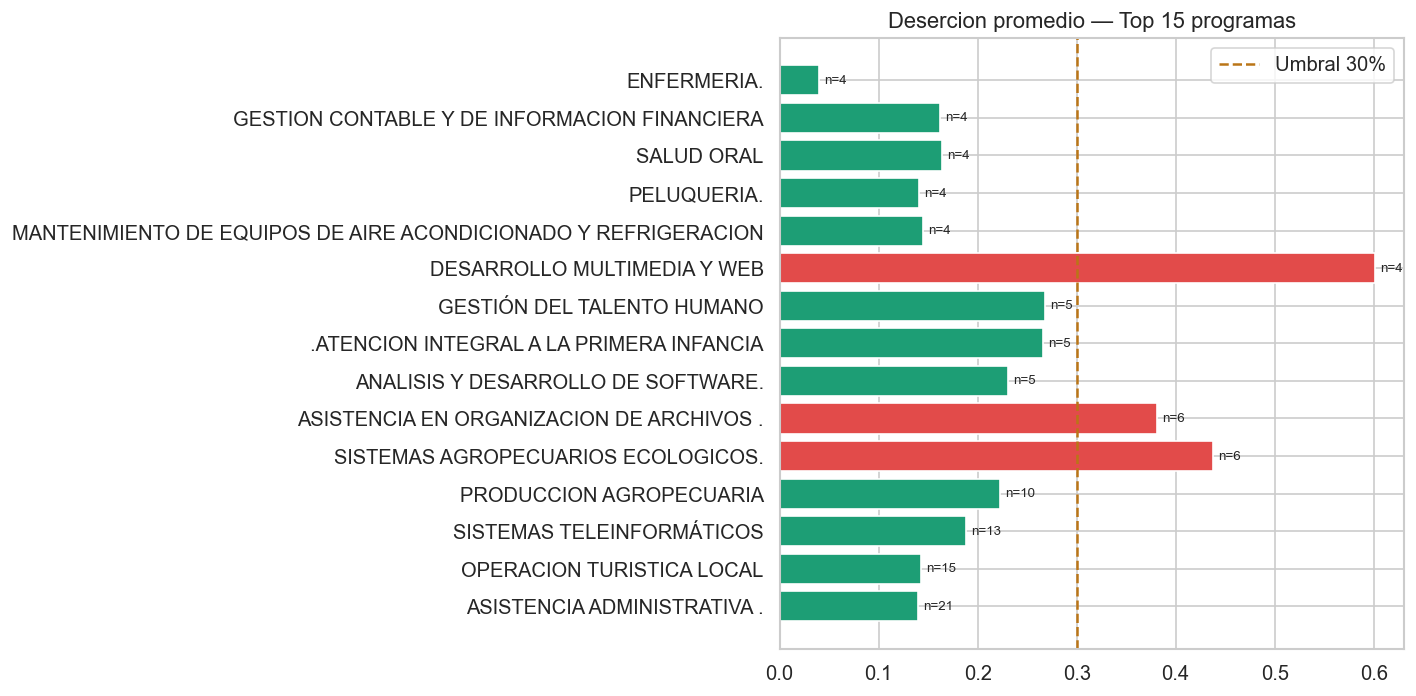

In [15]:
prog_stats = df.groupby('PROGRAMA').agg(
    FICHAS=('FICHA','count'),
    DESERCION_PROM=('TASA_DESERCION','mean')
).sort_values('FICHAS', ascending=False).head(15).round(3)

fig, ax = plt.subplots(figsize=(12,6))
colors_prog = ['#E24B4A' if d>=0.30 else '#1D9E75' for d in prog_stats['DESERCION_PROM']]
bars = ax.barh(prog_stats.index, prog_stats['DESERCION_PROM'], color=colors_prog, edgecolor='white')
ax.axvline(0.30, color='#BA7517', linestyle='--', linewidth=1.5, label='Umbral 30%')
ax.set_title('Desercion promedio — Top 15 programas')
ax.legend()
for bar, n in zip(bars, prog_stats['FICHAS']):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2, f'n={n}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

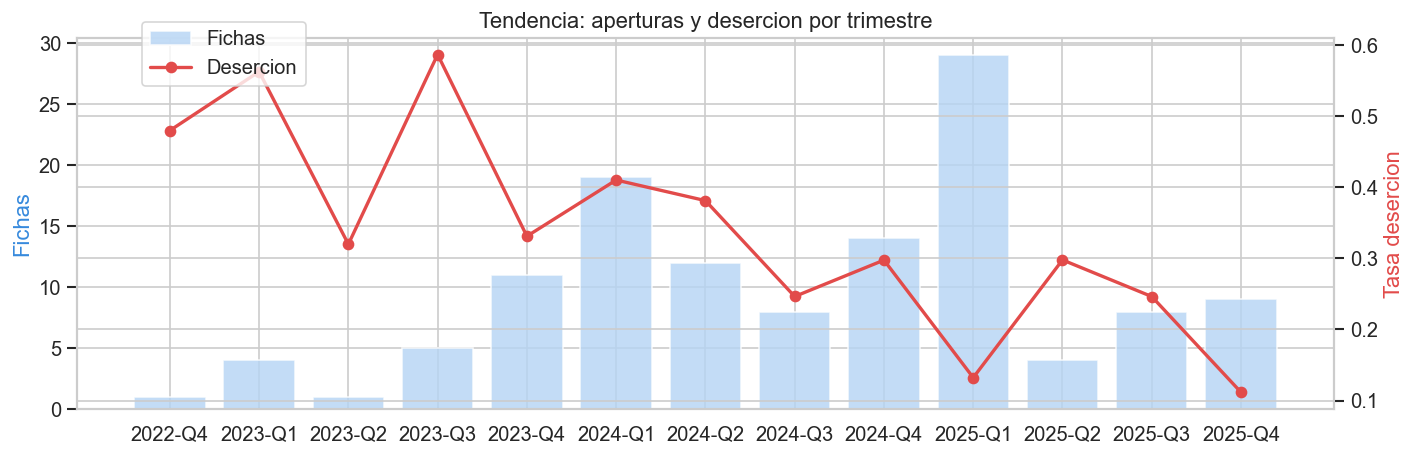

In [16]:
trend = df.groupby(['AÑO_APERTURA','TRIMESTRE_APERTURA']).agg(
    FICHAS=('FICHA','count'), DESERCION=('TASA_DESERCION','mean')
).reset_index()
trend['PERIODO'] = trend['AÑO_APERTURA'].astype(str) + '-Q' + trend['TRIMESTRE_APERTURA'].astype(str)
trend = trend[trend['AÑO_APERTURA'] < 2026]

fig, ax1 = plt.subplots(figsize=(12,4))
ax2 = ax1.twinx()
ax1.bar(trend['PERIODO'], trend['FICHAS'], color='#B5D4F4', alpha=0.8, label='Fichas')
ax2.plot(trend['PERIODO'], trend['DESERCION'], color='#E24B4A', marker='o', linewidth=2, label='Desercion')
ax1.set_ylabel('Fichas', color='#378ADD')
ax2.set_ylabel('Tasa desercion', color='#E24B4A')
ax1.set_title('Tendencia: aperturas y desercion por trimestre')
plt.xticks(rotation=45, ha='right')
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.95))
plt.tight_layout(); plt.show()

## 6. Preparación para el modelado

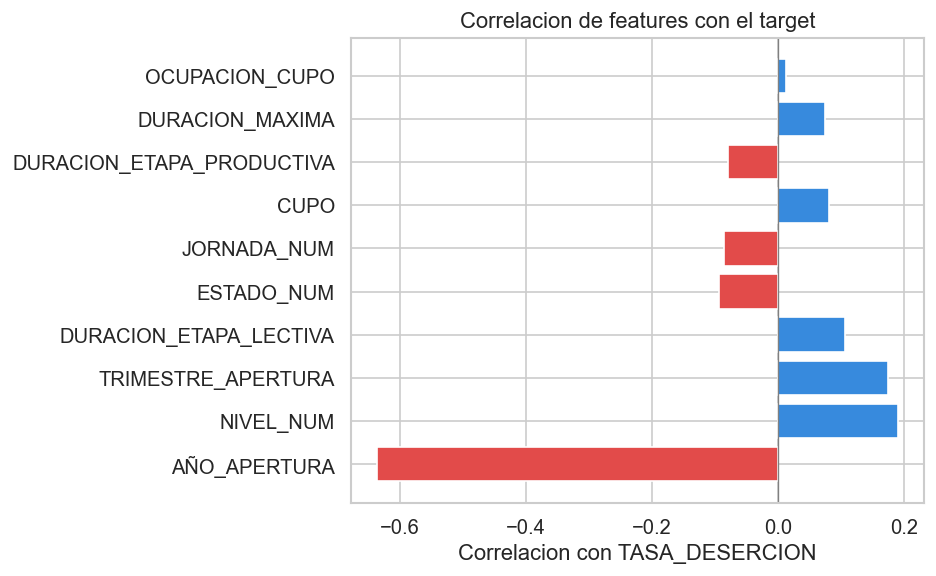

AÑO_APERTURA                -0.636952
NIVEL_NUM                    0.190510
TRIMESTRE_APERTURA           0.173645
DURACION_ETAPA_LECTIVA       0.105933
ESTADO_NUM                  -0.093418
JORNADA_NUM                 -0.086332
CUPO                         0.080304
DURACION_ETAPA_PRODUCTIVA   -0.079646
DURACION_MAXIMA              0.073756
OCUPACION_CUPO               0.012612


In [17]:
df_enc = df.copy()
df_enc['NIVEL_NUM'] = df_enc['NIVEL_FORMACION'].map({'TÉCNICO':0,'TECNÓLOGO':1,'OPERARIO':2})
df_enc['JORNADA_NUM'] = pd.factorize(df_enc['JORNADA'])[0]
df_enc['ESTADO_NUM'] = pd.factorize(df_enc['ESTADO_FICHA'])[0]

features_check = ['CUPO','DURACION_MAXIMA','DURACION_ETAPA_LECTIVA','DURACION_ETAPA_PRODUCTIVA',
                  'OCUPACION_CUPO','TRIMESTRE_APERTURA','AÑO_APERTURA',
                  'NIVEL_NUM','JORNADA_NUM','ESTADO_NUM']

corr_target = df_enc[features_check+['TASA_DESERCION']].corr()['TASA_DESERCION'].drop('TASA_DESERCION')
corr_target = corr_target.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
colors_corr = ['#E24B4A' if v<0 else '#378ADD' for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Correlacion con TASA_DESERCION')
ax.set_title('Correlacion de features con el target')
plt.tight_layout(); plt.show()

print(corr_target.to_string())

In [18]:
corr_feat = df_enc[features_check].corr().abs()
upper = corr_feat.where(np.triu(np.ones(corr_feat.shape), k=1).astype(bool))
redundantes = [(col,row,round(corr_feat.loc[row,col],3))
               for col in upper.columns for row in upper.index
               if not pd.isna(upper.loc[row,col]) and upper.loc[row,col]>0.85]
print('Variables con correlacion > 0.85 (posible redundancia):')
for a,b,c in sorted(redundantes, key=lambda x:-x[2]):
    print(f'  {a} <-> {b}: {c}')

Variables con correlacion > 0.85 (posible redundancia):
  DURACION_ETAPA_LECTIVA <-> DURACION_MAXIMA: 0.98


## 7. Hallazgos y conclusiones

In [ ]:
print('='*65)
print('RESUMEN DE HALLAZGOS EDA')
print('='*65)

print('\n1. VARIABLES CON MAYOR RELACION CON EL TARGET (TASA_DESERCION)')
for var, val in corr_target.abs().nlargest(3).items():
    print(f'   -> {var}: r = {corr_target[var]:.3f}')

print('\n2. DESBALANCE DE CLASES')
balance = df['ALTA_DESERCION'].value_counts(normalize=True)
print(f'   Baja desercion (<30%): {balance[0]*100:.1f}%')
print(f'   Alta desercion (>=30%): {balance[1]*100:.1f}%')
print('   -> Desbalance leve: aplicar class_weight=balanced o SMOTE')

print('\n3. VARIABLES QUE REQUIEREN TRANSFORMACION')
print('   -> NIVEL_FORMACION: codificacion ordinal')
print('   -> JORNADA: one-hot encoding')
print('   -> ESTADO_FICHA: binaria (terminada=1)')
print('   -> CUPO, TOTAL_MATRICULADOS: considerar log-transform')

print('\n4. VARIABLES REDUNDANTES / DATA LEAKAGE')
print('   -> TOTAL_DESERCION: derivada directa del target')
print('   -> TASA_CERTIFICACION: correlacion inversa fuerte con target')
print('   -> CERTIFICADO, RETIRO_VOLUNTARIO, CANCELADO: componen el target')
print('   -> DURACION_ETAPA_LECTIVA: r=0.98 con DURACION_MAXIMA (redundante)')

print('\n5. FEATURES SELECCIONADAS PARA MODELADO')
features_modelo = ['NIVEL_FORMACION','JORNADA','TRIMESTRE_APERTURA','ANO_APERTURA',
                   'CUPO','DURACION_MAXIMA','OCUPACION_CUPO','PROGRAMA_ESPECIAL']
for f in features_modelo:
    print(f'   check {f}')

print('\n6. HALLAZGOS DE CONTEXTO')
for n, v in df.groupby('NIVEL_FORMACION')['TASA_DESERCION'].mean().sort_values(ascending=False).items():
    print(f'   -> {n}: desercion promedio {v*100:.1f}%')
best_q = df.groupby('TRIMESTRE_APERTURA')['TASA_DESERCION'].mean().idxmin()
print(f'   -> Trimestre con menor desercion historica: Q{best_q}')
print(f'   -> ANO_APERTURA es el predictor mas correlacionado (r=-0.64)')
print(f'      Interpretacion: la desercion ha disminuido con el tiempo')
print('='*65)

RESUMEN DE HALLAZGOS EDA

1. VARIABLES CON MAYOR RELACION CON EL TARGET (TASA_DESERCION)
   -> AÑO_APERTURA: r = -0.637
   -> NIVEL_NUM: r = 0.191
   -> TRIMESTRE_APERTURA: r = 0.174

2. DESBALANCE DE CLASES
   Baja desercion (<30%): 66.0%
   Alta desercion (>=30%): 34.0%
   -> Desbalance leve: aplicar class_weight=balanced o SMOTE

3. VARIABLES QUE REQUIEREN TRANSFORMACION
   -> NIVEL_FORMACION: codificacion ordinal
   -> JORNADA: one-hot encoding
   -> ESTADO_FICHA: binaria (terminada=1)
   -> CUPO, TOTAL_MATRICULADOS: considerar log-transform

4. VARIABLES REDUNDANTES / DATA LEAKAGE
   -> TOTAL_DESERCION: derivada directa del target
   -> TASA_CERTIFICACION: correlacion inversa fuerte con target
   -> CERTIFICADO, RETIRO_VOLUNTARIO, CANCELADO: componen el target
   -> DURACION_ETAPA_LECTIVA: r=0.98 con DURACION_MAXIMA (redundante)

5. FEATURES SELECCIONADAS PARA MODELADO
   check NIVEL_FORMACION
   check JORNADA
   check TRIMESTRE_APERTURA
   check ANO_APERTURA
   check CUPO
   chec

: 